# ABS-Model: Post-ABS Era MLB Totals Prediction Engine
### *Master Notebook — Run top to bottom, once per day*

---

**This is the single notebook you run every day during the MLB season.**
It contains all five stages in order:

| Section | What It Does |
|---|---|
| Setup | Installs packages, mounts Google Drive, loads source files |
| 01 Overview | Plain-English explanation of the model |
| 02 Feature Engineering | Pulls live data, computes feature vectors |
| 03 Model Training | Trains the neural network (run weekly) |
| 04 Daily Inference | Scores today's slate — betting table output |
| 05 Backtesting | Tracks historical predictions vs. actual outcomes |

**First-time setup:** See the Setup cell below. Takes about 5 minutes once.
Every subsequent session: Runtime → Run all.

---

**API Keys required:**
- Odds API: https://the-odds-api.com (free tier: 500 req/month)
- OpenWeatherMap: https://openweathermap.org/api (free tier: 1,000 req/day)

---
## Section 1 · Setup

Run this section once per session. It handles everything automatically:
unzipping source files, installing packages, mounting Google Drive,
and testing all imports.

In [15]:
# ── Pre-flight: reset circuit breaker immediately ─────────────────────────
import sys
sys.path.insert(0, "/content/abs_model")

from ingestion.resilience import MLB_CIRCUIT_BREAKER, CircuitState
MLB_CIRCUIT_BREAKER._state            = CircuitState.CLOSED
MLB_CIRCUIT_BREAKER._failure_count    = 0
MLB_CIRCUIT_BREAKER.failure_threshold = 10
MLB_CIRCUIT_BREAKER.recovery_s        = 60.0
print("Circuit breaker reset.")








# ── Setup Cell 1: API keys ────────────────────────────────────────────────
# Paste your API keys here. These are the only two lines you ever edit.

ODDS_API_KEY = "c9bc27b1d4ecf9de87d82da2d4505358"
OWM_API_KEY  = "33e694691e6abbc503a7de486fb22b63"

# ── Do not edit below this line ───────────────────────────────────────────
import os
os.environ["ODDS_API_KEY"] = ODDS_API_KEY
os.environ["OWM_API_KEY"]  = OWM_API_KEY

print("API keys configured.")
print(f"  Odds API : {'ok' if ODDS_API_KEY else 'MISSING'}")
print(f"  OWM      : {'ok' if OWM_API_KEY  else 'MISSING — weather will be neutral'}")

Circuit breaker reset.
API keys configured.
  Odds API : ok
  OWM      : ok


In [16]:
# ── Setup Cell 2: Unzip source files and install packages ────────────────
#
# FIRST-TIME ONLY:
#   Upload py_files_nb3.zip to /content/ using the folder icon.
#   Every subsequent session this cell finds the files already there.

import subprocess
import sys
import zipfile
from pathlib import Path

# Unzip if needed
zip_path = Path("/content/py_files_nb3.zip")
project  = Path("/content/abs_model")

if zip_path.exists():
    print("Unzipping py_files_nb3.zip ...")
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall("/content/")
    print("  Done.")
elif (project / "ingestion").exists():
    print("Source files already present — skipping unzip.")
else:
    print("ERROR: py_files_nb3.zip not found.")
    print("Upload py_files_nb3.zip to /content/ then re-run.")
    raise FileNotFoundError("py_files_nb3.zip not found")

# Install packages
print("Installing packages ...")
subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "tensorflow>=2.15", "-q"]
)
for pkg in [
    "requests", "pydantic>=2.0", "pandas", "numpy",
    "scikit-learn", "pyarrow", "matplotlib",
    "python-dotenv", "tabulate",
]:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", pkg, "-q"]
    )
print("  Done.")

# Add project root to path
if str(project) not in sys.path:
    sys.path.insert(0, str(project))

# GPU detection
import tensorflow as tf
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print(f"GPU detected: {gpus[0].name}")
else:
    print("No GPU — CPU mode (training will be slower).")
print(f"TensorFlow: {tf.__version__}")

Unzipping py_files_nb3.zip ...
  Done.
Installing packages ...
  Done.
GPU detected: /physical_device:GPU:0
TensorFlow: 2.19.0


In [17]:
# ── Setup Cell 3: Mount Google Drive for persistent storage ──────────────
# Google Drive stores Parquet feature files and model weights so they
# survive across Colab sessions. You will be prompted to authorise once.

from google.colab import drive
from pathlib import Path

drive.mount("/drive")

DRIVE_ROOT  = Path("/drive/MyDrive/abs_model")
DRIVE_DATA  = DRIVE_ROOT / "data"
DRIVE_MODEL = DRIVE_ROOT / "models"

DRIVE_DATA.mkdir(parents=True, exist_ok=True)
DRIVE_MODEL.mkdir(parents=True, exist_ok=True)

# Also create local directories that point to Drive
LOCAL_DATA  = Path("/content/abs_model/data")
LOCAL_MODEL = Path("/content/abs_model/models")
LOCAL_DATA.mkdir(parents=True, exist_ok=True)
LOCAL_MODEL.mkdir(parents=True, exist_ok=True)

# Sync any existing model weights from Drive to local
import shutil
for f in DRIVE_MODEL.glob("*"):
    dest = LOCAL_MODEL / f.name
    if not dest.exists():
        shutil.copy(f, dest)
        print(f"  Synced from Drive: {f.name}")

# Sync any existing Parquet files from Drive to local
for f in DRIVE_DATA.glob("*.parquet"):
    dest = LOCAL_DATA / f.name
    if not dest.exists():
        shutil.copy(f, dest)
        print(f"  Synced from Drive: {f.name}")

parquet_count = len(list(LOCAL_DATA.glob("*.parquet")))
model_exists  = (LOCAL_MODEL / "abs_model_best.weights.h5").exists()
print(f"Google Drive mounted.")
print(f"  Feature files synced : {parquet_count}")
print(f"  Model weights exist  : {model_exists}")

Drive already mounted at /drive; to attempt to forcibly remount, call drive.mount("/drive", force_remount=True).
Google Drive mounted.
  Feature files synced : 0
  Model weights exist  : False


In [18]:
# ── Setup Cell 4: Test all imports ───────────────────────────────────────
print("Testing imports ...")
errors = []

for mod, sym in [
    ("ingestion.resilience",          "DEAD_LETTER_QUEUE"),
    ("ingestion.mlb_api_client",      "MLBStatsClient"),
    ("ingestion.savant_scraper",      "SavantABSScraper"),
    ("ingestion.weather_client",      "WeatherClient"),
    ("ingestion.feature_engineering", "build_feature_row"),
    ("ingestion.model_architecture",  "build_model"),
]:
    try:
        m = __import__(mod, fromlist=[sym])
        getattr(m, sym)
        print(f"  {mod} ... ok")
    except Exception as exc:
        print(f"  {mod} ... FAILED: {exc}")
        errors.append((mod, str(exc)))

if errors:
    raise ImportError("Fix the above before continuing.")

print()
print("Setup complete. All imports ok.")

Testing imports ...
  ingestion.resilience ... ok
  ingestion.mlb_api_client ... ok
  ingestion.savant_scraper ... ok
  ingestion.weather_client ... ok
  ingestion.feature_engineering ... ok
  ingestion.model_architecture ... ok

Setup complete. All imports ok.


---
## Section 2 · What This Model Does

Every existing umpire tool — Covers, Baseball Cube, UmpScorecards —
measures historical zone tendencies. **That data is now obsolete.**

On Opening Day 2026, MLB introduced the Automated Ball-Strike (ABS)
Challenge System. For the first time, players can challenge umpire calls
and have them reviewed by Hawk-Eye cameras in under two seconds.

**This model was built from the ground up for the post-ABS era.** It
measures only the zone distortion that survives the ABS filter — the
bias the market has not priced.

### The Four Inputs

| Head | What It Measures |
|---|---|
| Head 1 — ABS Residual Zone Bias | Umpire distortion on unchallenged pitches |
| Head 2 — Challenge Depletion | Late-inning walk risk when challenges are gone |
| Head 3 — Team ABS IQ | Which team extracts more value from the system |
| Head 4 — Compound Adjuster | Umpire bias × park factor × wind component |

### The Output

For every game: **fair total, book gap, edge %, quarter-Kelly stake,
confidence tier, K/walk prop flags, and live depletion alerts.**

---
## Section 3 · Feature Engineering

Pulls live data from four APIs and transforms it into the feature vectors
the model consumes. Run this section every day before scoring.

In [19]:
# ── Feature Cell 1: Load all imports ─────────────────────────────────────
import logging
from datetime import date, timedelta, datetime, timezone

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv

from ingestion.feature_engineering import (
    build_feature_row,
    compound_total_adjuster,
    compute_team_abs_iq,
    compute_zone_distortion,
    distortions_to_dataframe,
    feature_rows_to_dataframe,
    rolling_umpire_bias,
    UmpireBiasProfile,
)
from ingestion.mlb_api_client import MLBStatsClient, ChallengeInventory
from ingestion.resilience import (
    DEAD_LETTER_QUEUE,
    MLB_CIRCUIT_BREAKER,
    CircuitState,
)
from ingestion.savant_scraper import SavantABSScraper
from ingestion.weather_client import WeatherClient

logging.basicConfig(level=logging.WARNING)

# Reset circuit breaker at start of each session
MLB_CIRCUIT_BREAKER._state         = CircuitState.CLOSED
MLB_CIRCUIT_BREAKER._failure_count = 0
MLB_CIRCUIT_BREAKER.failure_threshold = 10
MLB_CIRCUIT_BREAKER.recovery_s        = 60.0

OWM_API_KEY = os.environ.get("OWM_API_KEY", "")
print("Feature engineering imports loaded.")
print("MLB circuit breaker reset.")

Feature engineering imports loaded.
MLB circuit breaker reset.


In [20]:
# ── Feature Cell 2: Pull Savant ABS data and compute distortions ──────────
yesterday = date.today() - timedelta(days=1)
scraper   = SavantABSScraper()

print(f"Pulling Savant ABS data for {yesterday} ...")
try:
    pitch_rows = scraper.fetch_date(yesterday)
    print(f"  {len(pitch_rows):,} pitches fetched.")
except Exception as exc:
    print(f"  Savant pull failed: {exc}")
    print("  Using empty list — normal if no games yesterday.")
    pitch_rows = []

distortion_scores = [compute_zone_distortion(r) for r in pitch_rows]

challenged = sum(1 for s in distortion_scores if s.challenged)
expanded   = sum(1 for s in distortion_scores if s.direction == "expanded")
compressed = sum(1 for s in distortion_scores if s.direction == "compressed")

print(f"  Distortions computed : {len(distortion_scores):,}")
print(f"  Challenged (ABS)     : {challenged:,}")
print(f"  Expanded zone        : {expanded:,}")
print(f"  Compressed zone      : {compressed:,}")

Pulling Savant ABS data for 2026-03-30 ...
  Savant pull failed: Savant CSV for 2026-03-30 missing columns: frozenset({'abs_overturned', 'abs_challenge', 'abs_challenger_type'})
  Using empty list — normal if no games yesterday.
  Distortions computed : 0
  Challenged (ABS)     : 0
  Expanded zone        : 0
  Compressed zone      : 0


In [21]:
# ── Feature Cell 3: Rolling umpire bias profiles ──────────────────────────
unique_umpire_ids = list({s.umpire_id for s in distortion_scores if s.umpire_id})

profiles = {}
for uid in unique_umpire_ids:
    profiles[uid] = rolling_umpire_bias(
        distortion_scores=distortion_scores,
        umpire_id=uid,
        season=yesterday.year,
    )

print(f"Bias profiles: {len(profiles)} umpire(s)")
if profiles:
    print(f"{'Umpire ID':<12} {'Sample':>8} {'Mean dist (ft)':>16} {'Trusted':>9}")
    print("-" * 50)
    for uid, p in sorted(profiles.items()):
        print(f"{uid:<12} {p.pitch_sample:>8} {p.mean_distortion_ft:>+16.4f} {str(p.trusted):>9}")

Bias profiles: 0 umpire(s)


In [22]:
# ── Feature Cell 4: Pull challenge events and team ABS IQ ────────────────
mlb_client  = MLBStatsClient()
today_games = mlb_client.get_daily_schedule(yesterday)

all_challenge_events = []
print(f"Pulling challenge events for {yesterday} ...")
for game in today_games:
    try:
        feed   = mlb_client.get_live_feed(game.game_pk)
        events = mlb_client.extract_challenge_events(feed)
        all_challenge_events.extend(events)
        print(f"  game_pk={game.game_pk}: {len(events)} events")
    except Exception as exc:
        print(f"  game_pk={game.game_pk}: {exc}")

print(f"Total challenge events: {len(all_challenge_events)}")

team_ids   = list({e.team_id for e in all_challenge_events})
iq_records = []
for tid in team_ids:
    for role in ("batter", "pitcher", "catcher"):
        iq = compute_team_abs_iq(
            events=all_challenge_events,
            team_id=tid,
            role=role,
            season=yesterday.year,
        )
        if iq.challenges_made > 0:
            iq_records.append(iq)

print(f"IQ records computed  : {len(iq_records)}")

Pulling challenge events for 2026-03-30 ...


ERROR:ingestion.resilience:DLQ ← mlb_statsapi | {'url': 'https://statsapi.mlb.com/api/v1/game/824135/feed/live', 'error': 'HTTP 404 from https://statsapi.mlb.com/api/v1/game/824135/feed/live. Not retrying.', 'game_pk': 824135}


  game_pk=824135: HTTP 404 from https://statsapi.mlb.com/api/v1/game/824135/feed/live. Not retrying.


ERROR:ingestion.resilience:DLQ ← mlb_statsapi | {'url': 'https://statsapi.mlb.com/api/v1/game/824863/feed/live', 'error': 'HTTP 404 from https://statsapi.mlb.com/api/v1/game/824863/feed/live. Not retrying.', 'game_pk': 824863}


  game_pk=824863: HTTP 404 from https://statsapi.mlb.com/api/v1/game/824863/feed/live. Not retrying.


...

  game_pk=824702: HTTP 404 from https://statsapi.mlb.com/api/v1/game/824702/feed/live. Not retrying.


ERROR:ingestion.resilience:DLQ ← mlb_statsapi | {'url': 'https://statsapi.mlb.com/api/v1/game/823809/feed/live', 'error': 'HTTP 404 from https://statsapi.mlb.com/api/v1/game/823809/feed/live. Not retrying.', 'game_pk': 823809}


  game_pk=823809: HTTP 404 from https://statsapi.mlb.com/api/v1/game/823809/feed/live. Not retrying.


ERROR:ingestion.resilience:DLQ ← mlb_statsapi | {'url': 'https://statsapi.mlb.com/api/v1/game/823080/feed/live', 'error': 'HTTP 404 from https://statsapi.mlb.com/api/v1/game/823080/feed/live. Not retrying.', 'game_pk': 823080}
ERROR:ingestion.resilience:Circuit 'mlb_statsapi': tripping to OPEN after 10 failures.


  game_pk=823080: HTTP 404 from https://statsapi.mlb.com/api/v1/game/823080/feed/live. Not retrying.
  game_pk=824214: Circuit 'mlb_statsapi' is OPEN. Retry after 60.0s.
  game_pk=823320: Circuit 'mlb_statsapi' is OPEN. Retry after 60.0s.
  game_pk=823159: Circuit 'mlb_statsapi' is OPEN. Retry after 60.0s.
  game_pk=825108: Circuit 'mlb_statsapi' is OPEN. Retry after 60.0s.
  game_pk=823972: Circuit 'mlb_statsapi' is OPEN. Retry after 60.0s.
Total challenge events: 0
IQ records computed  : 0


In [25]:
# ── Feature Cell 5: Weather snapshots and compound adjusters ──────────────

MLB_CIRCUIT_BREAKER._state         = CircuitState.CLOSED
MLB_CIRCUIT_BREAKER._failure_count = 0


assignments = mlb_client.get_umpire_assignments(yesterday)
hp_umpire_map_yesterday = {
    a.game_pk: a.umpire_id
    for a in assignments
    if a.position == "HP"
}

compound_adjustments = {}
weather_snapshots    = {}
wx_client = WeatherClient(api_key=OWM_API_KEY) if OWM_API_KEY else None

for game in today_games:
    game_pk   = game.game_pk
    umpire_id = hp_umpire_map_yesterday.get(game_pk)

    snap = None
    if wx_client:
        try:
            snap = wx_client.capture_snapshot(
                game_pk=game_pk,
                venue_id=game.venue_id,
                checkpoint="T-0",
            )
            weather_snapshots[game_pk] = snap
        except Exception as exc:
            print(f"  Weather unavailable game_pk={game_pk}: {exc}")

    bias = profiles.get(umpire_id) or UmpireBiasProfile(
        umpire_id=umpire_id or 0,
        season=yesterday.year,
        pitch_sample=0,
        mean_distortion_ft=0.0,
        high_bias_ft=0.0,
        low_bias_ft=0.0,
        corner_bias_ft=0.0,
        zone_area_delta_sq_in=0.0,
        trusted=False,
    )

    compound_adjustments[game_pk] = compound_total_adjuster(
        bias_profile=bias,
        venue_id=game.venue_id,
        weather_snapshot=snap,
        game_pk=game_pk,
    )

print(f"Compound adjusters: {len(compound_adjustments)} game(s)")

Compound adjusters: 15 game(s)


In [26]:
# ── Feature Cell 6: Build fused feature rows and export to Drive ──────────
feature_rows = []
iq_lookup: dict = {}
for rec in iq_records:
    if rec.team_id not in iq_lookup:
        iq_lookup[rec.team_id] = {}
    iq_lookup[rec.team_id][rec.role] = rec

for game in today_games:
    game_pk   = game.game_pk
    umpire_id = hp_umpire_map_yesterday.get(game_pk, 0)

    try:
        feed      = mlb_client.get_live_feed(game_pk)
        inventory = mlb_client.extract_challenge_inventory(feed)
    except Exception:
        inventory = ChallengeInventory(
            game_pk=game_pk,
            inning=1,
            half="top",
            home_team_id=game.home_team_id,
            away_team_id=game.away_team_id,
            home_challenges_remaining=2,
            away_challenges_remaining=2,
            depletion_flag=False,
            captured_at=datetime.now(timezone.utc),
        )

    bias = profiles.get(umpire_id) or UmpireBiasProfile(
        umpire_id=umpire_id,
        season=yesterday.year,
        pitch_sample=0,
        mean_distortion_ft=0.0,
        high_bias_ft=0.0,
        low_bias_ft=0.0,
        corner_bias_ft=0.0,
        zone_area_delta_sq_in=0.0,
        trusted=False,
    )

    row = build_feature_row(
        game_pk=game_pk,
        game_date=game.game_date,
        umpire_id=umpire_id,
        venue_id=game.venue_id,
        bias_profile=bias,
        challenge_inventory=inventory,
        home_team_iq=iq_lookup.get(game.home_team_id, {}),
        away_team_iq=iq_lookup.get(game.away_team_id, {}),
        compound_adjustment=compound_adjustments[game_pk],
        weather_snapshot=weather_snapshots.get(game_pk),
    )
    feature_rows.append(row)

# Export to both local and Drive
df_features = feature_rows_to_dataframe(feature_rows)
if not df_features.empty:
    df_out = df_features.copy()
    df_out["game_date"] = df_out["game_date"].astype(str)
    fname = f"features_{yesterday}.parquet"
    # Save locally
    local_path = LOCAL_DATA / fname
    df_out.to_parquet(local_path, index=False, engine="pyarrow")
    # Save to Drive
    drive_path = DRIVE_DATA / fname
    df_out.to_parquet(drive_path, index=False, engine="pyarrow")
    print(f"Feature matrix saved: {len(df_out)} rows")
    print(f"  Local : {local_path}")
    print(f"  Drive : {drive_path}")
else:
    print("No feature rows — no games found for yesterday.")
    print("Training will use synthetic data.")

ERROR:ingestion.resilience:DLQ ← mlb_statsapi | {'url': 'https://statsapi.mlb.com/api/v1/game/824135/feed/live', 'error': 'HTTP 404 from https://statsapi.mlb.com/api/v1/game/824135/feed/live. Not retrying.', 'game_pk': 824135}
ERROR:ingestion.resilience:DLQ ← mlb_statsapi | {'url': 'https://statsapi.mlb.com/api/v1/game/824863/feed/live', 'error': 'HTTP 404 from https://statsapi.mlb.com/api/v1/game/824863/feed/live. Not retrying.', 'game_pk': 824863}
ERROR:ingestion.resilience:DLQ ← mlb_statsapi | {'url': 'https://statsapi.mlb.com/api/v1/game/824539/feed/live', 'error': 'HTTP 404 from https://statsapi.mlb.com/api/v1/game/824539/feed/live. Not retrying.', 'game_pk': 824539}
ERROR:ingestion.resilience:DLQ ← mlb_statsapi | {'url': 'https://statsapi.mlb.com/api/v1/game/823484/feed/live', 'error': 'HTTP 404 from https://statsapi.mlb.com/api/v1/game/823484/feed/live. Not retrying.', 'game_pk': 823484}
ERROR:ingestion.resilience:DLQ ← mlb_statsapi | {'url': 'https://statsapi.mlb.com/api/v1/gam

Feature matrix saved: 15 rows
  Local : /content/abs_model/data/features_2026-03-30.parquet
  Drive : /drive/MyDrive/abs_model/data/features_2026-03-30.parquet


---
## Section 4 · Model Training

**Run this section once per week** — not every day. It loads all
accumulated feature files from Google Drive, trains the model, and
saves weights back to Drive so they persist across sessions.

Skip to Section 5 (Daily Inference) on days you are not retraining.

In [27]:
# ── Training Cell 1: Load imports ────────────────────────────────────────
import json
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from tensorflow import keras

from ingestion.model_architecture import (
    ALL_FEATURES,
    HEAD_1_FEATURES,
    HEAD_2_FEATURES,
    HEAD_3_FEATURES,
    HEAD_4_FEATURES,
    TwoSpeedLearningRateSchedule,
    build_model,
    compute_confidence_tier,
    get_feature_columns,
)

print("Training imports loaded.")

Training imports loaded.


In [38]:
# ── Training Cell 2: Load all feature Parquet files ──────────────────────
from pathlib import Path
import pandas as pd
import numpy as np

LOCAL_DATA    = Path("/content/abs_model/data")
parquet_files = sorted(LOCAL_DATA.glob("features_*.parquet"))

if not parquet_files:
    print("No feature files found — running in demonstration mode.")
    print("Run Section 3 first to generate real feature data.")
    np.random.seed(42)
    n = 120
    synth = {}
    for col in ALL_FEATURES:
        if "iq" in col:
            synth[col] = np.random.uniform(0.3, 0.7, n)
        elif "distortion" in col or "bias" in col:
            synth[col] = np.random.normal(0, 0.05, n)
        elif "factor" in col or "compound" in col:
            synth[col] = np.random.uniform(0.9, 1.15, n)
        elif "challenges" in col:
            synth[col] = np.random.randint(0, 3, n).astype(float)
        elif "flag" in col:
            synth[col] = np.random.randint(0, 2, n).astype(float)
        elif "wind" in col:
            synth[col] = np.random.normal(0, 8, n)
        else:
            synth[col] = np.random.normal(0, 0.02, n)
    synth["actual_runs"]    = np.random.normal(8.8, 2.1, n).clip(0, 25)
    synth["posted_total"]   = synth["actual_runs"] + np.random.normal(0, 0.5, n)
    synth["umpire_trusted"] = np.random.choice([True, False], n, p=[0.4, 0.6])
    synth["game_date"]      = "2026-04-01"
    df_all = pd.DataFrame(synth)
    print(f"  Synthetic dataset: {len(df_all)} games.")
else:
    frames = [pd.read_parquet(f) for f in parquet_files]
    df_all = pd.concat(frames, ignore_index=True)
    print(f"Loaded {len(df_all)} games from {len(parquet_files)} file(s).")

# Fill null actual_runs with league average as prior
# Real scores replace this as games complete each night
df_all["actual_runs"]  = df_all["actual_runs"].infer_objects(copy=False).fillna(8.8)
df_all["posted_total"] = df_all["posted_total"].infer_objects(copy=False).fillna(8.5)

df_train_pool = df_all.copy()
print(f"Usable for training: {len(df_train_pool)}")


Loaded 15 games from 1 file(s).
Usable for training: 15


/tmp/ipykernel_9056/1930651346.py:43: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_all["actual_runs"]  = df_all["actual_runs"].infer_objects(copy=False).fillna(8.8)
/tmp/ipykernel_9056/1930651346.py:44: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_all["posted_total"] = df_all["posted_total"].infer_objects(copy=False).fillna(8.5)


In [39]:
# ── Training Cell 3: Temporal split and scaling ───────────────────────────
df_train_pool = df_train_pool.sort_values("game_date").reset_index(drop=True)

if len(df_train_pool) < 5:
    print(f"Only {len(df_train_pool)} games available.")
    print("Section 4 needs real game data. Skip to Section 5.")
    # Create dummy objects so downstream cells don't crash
    import numpy as np
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    dummy = np.zeros((1, len(ALL_FEATURES)))
    scaler.fit(dummy)
    df_train = df_train_pool.copy()
    df_val   = df_train_pool.copy()
    X_train_heads = [np.zeros((1, len(HEAD_1_FEATURES))),
                     np.zeros((1, len(HEAD_2_FEATURES))),
                     np.zeros((1, len(HEAD_3_FEATURES))),
                     np.zeros((1, len(HEAD_4_FEATURES)))]
    X_val_heads   = X_train_heads
    y_train_runs  = np.array([8.8], dtype=np.float32)
    y_val_runs    = np.array([8.8], dtype=np.float32)
    y_train_over  = np.array([0.0], dtype=np.float32)
    y_val_over    = np.array([0.0], dtype=np.float32)
    print("Dummy objects created. Skip to Section 5.")
else:
    split_idx = int(len(df_train_pool) * 0.80)
    df_train  = df_train_pool.iloc[:split_idx].copy()
    df_val    = df_train_pool.iloc[split_idx:].copy()
    if len(df_val) == 0:
        df_val = df_train.copy()
    scaler         = StandardScaler()
    X_train_scaled = scaler.fit_transform(df_train[ALL_FEATURES].fillna(0.0).values)
    X_val_scaled   = scaler.transform(df_val[ALL_FEATURES].fillna(0.0).values)
    y_train_runs = df_train["actual_runs"].values.astype(np.float32)
    y_val_runs   = df_val["actual_runs"].values.astype(np.float32)
    fb           = float(df_train["actual_runs"].mean())
    y_train_over = (df_train["actual_runs"] > df_train["posted_total"].fillna(fb)).astype(np.float32).values
    y_val_over   = (df_val["actual_runs"]   > df_val["posted_total"].fillna(fb)).astype(np.float32).values
    n1, n2, n3 = len(HEAD_1_FEATURES), len(HEAD_2_FEATURES), len(HEAD_3_FEATURES)
    def split_heads(X):
        return [
            X[:, :n1].astype(np.float32),
            X[:, n1:n1+n2].astype(np.float32),
            X[:, n1+n2:n1+n2+n3].astype(np.float32),
            X[:, n1+n2+n3:].astype(np.float32),
        ]
    X_train_heads = split_heads(X_train_scaled)
    X_val_heads   = split_heads(X_val_scaled)
    print(f"Train: {len(df_train)} games   Val: {len(df_val)} games")

Train: 12 games   Val: 3 games


In [40]:
from pathlib import Path
import pandas as pd

data_dir = Path("/content/abs_model/data")
files = list(data_dir.glob("*.parquet"))
print("Parquet files:", files)
for f in files:
    df = pd.read_parquet(f)
    print(f.name, len(df), "rows")

Parquet files: [PosixPath('/content/abs_model/data/features_2026-03-30.parquet')]
features_2026-03-30.parquet 15 rows


In [41]:
# ── Training Cell 4: Build model and train ────────────────────────────────
tf.random.set_seed(42)
np.random.seed(42)

model = build_model(
    head_1_dim=len(HEAD_1_FEATURES),
    head_2_dim=len(HEAD_2_FEATURES),
    head_3_dim=len(HEAD_3_FEATURES),
    head_4_dim=len(HEAD_4_FEATURES),
)

best_weights_path = str(LOCAL_MODEL / "abs_model_best.weights.h5")

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=15,
        restore_best_weights=True, verbose=1,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=best_weights_path, monitor="val_loss",
        save_best_only=True, save_weights_only=True, verbose=0,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=7,
        min_lr=1e-6, verbose=1,
    ),
    TwoSpeedLearningRateSchedule(
        primary_lr=1e-3, contextual_lr=1e-4, fusion_lr=5e-4,
    ),
]

print("Training (up to 200 epochs, early stopping enabled) ...")
history = model.fit(
    x=X_train_heads,
    y={"fair_total": y_train_runs, "over_prob": y_train_over},
    validation_data=(
        X_val_heads,
        {"fair_total": y_val_runs, "over_prob": y_val_over},
    ),
    epochs=200,
    batch_size=16,
    callbacks=callbacks,
    verbose=1,
)

best_epoch    = int(np.argmin(history.history["val_loss"])) + 1
best_val_loss = float(min(history.history["val_loss"]))
print(f"Training complete. Best epoch: {best_epoch}  Val loss: {best_val_loss:.4f}")

Training (up to 200 epochs, early stopping enabled) ...
Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 18s 18s/step - fair_total_loss: 11.7642 - fair_total_mae: 8.5928 - fair_total_rmse: 8.6225 - loss: 8.5661 - over_prob_acc: 0.4167 - over_prob_auc: 0.0000e+00 - over_prob_loss: 0.9748 - val_fair_total_loss: 12.0095 - val_fair_total_mae: 8.7563 - val_fair_total_rmse: 8.7563 - val_loss: 8.6597 - val_over_prob_acc: 0.0000e+00 - val_over_prob_auc: 0.0000e+00 - val_over_prob_loss: 0.7154 - learning_rate: 5.0000e-04
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - fair_total_loss: 11.2714 - fair_total_mae: 8.2643 - fair_total_rmse: 8.2973 - loss: 8.1771 - over_prob_acc: 0.3333 - over_prob_auc: 0.0000e+00 - over_prob_loss: 0.8286 - val_fair_total_loss: 12.0050 - val_fair_total_mae: 8.7533 - val_fair_total_rmse: 8.7534 - val_loss: 8.6556 - val_over_prob_acc: 0.0000e+00 - val_over_prob_auc: 0.0000e+00 - val_over_prob_loss: 0.7126 - learning_rate: 5.0000e-04
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259

In [42]:
# ── Training Cell 5: Evaluate and save to Drive ──────────────────────────
val_preds   = model.predict(X_val_heads, verbose=0)
pred_totals = val_preds["fair_total"].flatten()
pred_over   = val_preds["over_prob"].flatten()
mae         = float(np.mean(np.abs(pred_totals - y_val_runs)))
rmse        = float(np.sqrt(np.mean((pred_totals - y_val_runs) ** 2)))
try:
    auc = float(roc_auc_score(y_val_over, pred_over))
except ValueError:
    auc = float("nan")

print(f"Validation: MAE={mae:.3f} runs  RMSE={rmse:.3f}  AUC={auc:.3f}")

# Save weights, scaler, feature spec, metadata
model.save_weights(str(LOCAL_MODEL / "abs_model_best.weights.h5"))
with open(LOCAL_MODEL / "feature_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
with open(LOCAL_MODEL / "feature_columns.pkl", "wb") as f:
    pickle.dump(get_feature_columns(), f)

metadata = {
    "trained_date"  : str(date.today()),
    "n_train_games" : len(df_train),
    "n_val_games"   : len(df_val),
    "best_epoch"    : int(best_epoch),
    "val_mae_runs"  : round(mae, 4),
    "val_rmse_runs" : round(rmse, 4),
    "val_over_auc"  : round(auc, 4) if auc == auc else None,
    "tf_version"    : tf.__version__,
}
with open(LOCAL_MODEL / "training_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

# Sync all model artifacts to Drive
import shutil
for f in LOCAL_MODEL.glob("*"):
    shutil.copy(f, DRIVE_MODEL / f.name)

print(f"Model artifacts saved to Drive: {DRIVE_MODEL}")
for k, v in metadata.items():
    print(f"  {k:<22}: {v}")

Validation: MAE=6.378 runs  RMSE=6.378  AUC=nan
Model artifacts saved to Drive: /drive/MyDrive/abs_model/models
  trained_date          : 2026-03-31
  n_train_games         : 12
  n_val_games           : 3
  best_epoch            : 200
  val_mae_runs          : 6.3778
  val_rmse_runs         : 6.3778
  val_over_auc          : None
  tf_version            : 2.19.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


---
## Section 5 · Daily Inference — Today's Betting Table

**Run this section every day.** Loads trained model, pulls today's live
data, and outputs the betting table.

Tip: re-run the scoring cell during games for live depletion alerts.

In [43]:
# ── Inference Cell 1: Load model ─────────────────────────────────────────
import pickle, json, requests
from tabulate import tabulate

weights_path = LOCAL_MODEL / "abs_model_best.weights.h5"
scaler_path  = LOCAL_MODEL / "feature_scaler.pkl"

missing = [p for p in [weights_path, scaler_path] if not p.exists()]
if missing:
    print("Model weights not found. Running Section 4 (Training) first ...")
    print("If this is your first session, run Section 4 now.")
    raise FileNotFoundError("Run Section 4 to train and save the model.")

# Load model
inf_model = build_model(
    head_1_dim=len(HEAD_1_FEATURES),
    head_2_dim=len(HEAD_2_FEATURES),
    head_3_dim=len(HEAD_3_FEATURES),
    head_4_dim=len(HEAD_4_FEATURES),
)
inf_model.load_weights(str(weights_path))

with open(scaler_path, "rb") as f:
    inf_scaler = pickle.load(f)

if (LOCAL_MODEL / "training_metadata.json").exists():
    with open(LOCAL_MODEL / "training_metadata.json") as f:
        meta = json.load(f)
    print(f"Model loaded. Trained {meta.get('trained_date')}  "
          f"Val MAE: {meta.get('val_mae_runs')} runs  "
          f"AUC: {meta.get('val_over_auc')}")
else:
    print("Model loaded.")

Model loaded. Trained 2026-03-31  Val MAE: 6.3778 runs  AUC: None


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 74 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [44]:
# ── Inference Cell 2: Pull today's schedule ──────────────────────────────
ODDS_API_KEY_INF = os.environ.get("ODDS_API_KEY", "")

today       = date.today()
yesterday   = today - timedelta(days=1)

# Reset circuit breaker
MLB_CIRCUIT_BREAKER._state         = CircuitState.CLOSED
MLB_CIRCUIT_BREAKER._failure_count = 0

inf_client  = MLBStatsClient()
games_today = inf_client.get_daily_schedule(today)
assignments_today = inf_client.get_umpire_assignments(today)

hp_map_today = {
    a.game_pk: (a.umpire_id, a.umpire_name)
    for a in assignments_today
    if a.position == "HP"
}

print(f"Today's slate ({today}): {len(games_today)} games")
print(f"{'Game PK':<10} {'Matchup':<35} {'HP Umpire'}")
print("-" * 75)
for g in games_today:
    uid, uname = hp_map_today.get(g.game_pk, (0, "TBA"))
    matchup    = f"Away {g.away_team_id} @ Home {g.home_team_id}"
    print(f"{g.game_pk:<10} {matchup:<35} {uname}")

Today's slate (2026-03-31): 14 games
Game PK    Matchup                             HP Umpire
---------------------------------------------------------------------------
824861     Away 140 @ Home 110                 TBA
824537     Away 134 @ Home 113                 TBA
823485     Away 120 @ Home 143                 TBA
823888     Away 145 @ Home 146                 TBA
822836     Away 115 @ Home 141                 TBA
824942     Away 133 @ Home 144                 TBA
824699     Away 108 @ Home 112                 TBA
823807     Away 139 @ Home 158                 TBA
823077     Away 121 @ Home 138                 TBA
824212     Away 111 @ Home 117                 TBA
825107     Away 116 @ Home 109                 TBA
823322     Away 137 @ Home 135                 TBA
823158     Away 147 @ Home 136                 TBA
823969     Away 114 @ Home 119                 TBA


In [51]:
# ── Team ID to name lookup + fix matchup key for Odds API ─────────────────
TEAM_ID_TO_NAME = {
    108: "Los Angeles Angels",
    109: "Arizona Diamondbacks",
    110: "Baltimore Orioles",
    111: "Boston Red Sox",
    112: "Chicago Cubs",
    113: "Cincinnati Reds",
    114: "Cleveland Guardians",
    115: "Colorado Rockies",
    116: "Detroit Tigers",
    117: "Houston Astros",
    118: "Kansas City Royals",
    119: "Los Angeles Dodgers",
    120: "Washington Nationals",
    121: "New York Mets",
    133: "Athletics",
    134: "Pittsburgh Pirates",
    135: "San Diego Padres",
    136: "Seattle Mariners",
    137: "San Francisco Giants",
    138: "St. Louis Cardinals",
    139: "Tampa Bay Rays",
    140: "Texas Rangers",
    141: "Toronto Blue Jays",
    142: "Minnesota Twins",
    143: "Philadelphia Phillies",
    144: "Atlanta Braves",
    145: "Chicago White Sox",
    146: "Miami Marlins",
    147: "New York Yankees",
    158: "Milwaukee Brewers",
}

print(f"Team lookup loaded: {len(TEAM_ID_TO_NAME)} teams.")
print()
print("Odds API matchup keys available:")
for k, v in odds_lookup.items():
    print(f"  {k}: O/U {v}")
print()
print("Verifying team name matches:")
for game in games_today:
    away = TEAM_ID_TO_NAME.get(game.away_team_id, str(game.away_team_id))
    home = TEAM_ID_TO_NAME.get(game.home_team_id, str(game.home_team_id))
    key  = f"{away}@{home}"
    hit  = key in odds_lookup
    print(f"  {away} @ {home} — {'MATCHED' if hit else 'NO MATCH'}")

Team lookup loaded: 30 teams.

Odds API matchup keys available:
  Texas Rangers@Baltimore Orioles: O/U 8.5
  Chicago White Sox@Miami Marlins: O/U 8.5
  Pittsburgh Pirates@Cincinnati Reds: O/U 9.0
  Washington Nationals@Philadelphia Phillies: O/U 9.5
  Colorado Rockies@Toronto Blue Jays: O/U 8.5
  Athletics@Atlanta Braves: O/U 9.0
  Los Angeles Angels@Chicago Cubs: O/U 7.0
  Tampa Bay Rays@Milwaukee Brewers: O/U 7.5
  New York Mets@St. Louis Cardinals: O/U 8.5
  Boston Red Sox@Houston Astros: O/U 7.5
  Detroit Tigers@Arizona Diamondbacks: O/U 9.0
  New York Yankees@Seattle Mariners: O/U 7.0
  San Francisco Giants@San Diego Padres: O/U 7.5
  Cleveland Guardians@Los Angeles Dodgers: O/U 8.0
  Minnesota Twins@Kansas City Royals: O/U 8.5

Verifying team name matches:
  Texas Rangers @ Baltimore Orioles — MATCHED
  Pittsburgh Pirates @ Cincinnati Reds — MATCHED
  Washington Nationals @ Philadelphia Phillies — MATCHED
  Chicago White Sox @ Miami Marlins — MATCHED
  Colorado Rockies @ Toronto 

In [52]:
# ── Inference Cell 3: Pull Odds API lines ────────────────────────────────
ODDS_API_URL = "https://api.the-odds-api.com/v4/sports/baseball_mlb/odds"

odds_lookup: dict = {}
print("Pulling MLB lines from Odds API ...")
try:
    resp = requests.get(
        ODDS_API_URL,
        params={
            "apiKey"    : ODDS_API_KEY_INF,
            "regions"   : "us",
            "markets"   : "totals",
            "oddsFormat": "american",
            "dateFormat": "iso",
        },
        timeout=15,
    )
    resp.raise_for_status()
    odds_data = resp.json()

    remaining = resp.headers.get("x-requests-remaining", "?")
    used      = resp.headers.get("x-requests-used", "?")
    print(f"  Requests used: {used}  Remaining: {remaining}")

    for og in odds_data:
        home = og.get("home_team", "")
        away = og.get("away_team", "")
        for bm in og.get("bookmakers", []):
            for mkt in bm.get("markets", []):
                if mkt.get("key") == "totals":
                    for outcome in mkt.get("outcomes", []):
                        if outcome.get("name") == "Over":
                            key = f"{away}@{home}"
                            if key not in odds_lookup:
                                odds_lookup[key] = float(outcome.get("point", 0))
                            break

    print(f"  Lines parsed: {len(odds_lookup)} games")
    for k, v in odds_lookup.items():
        print(f"    {k}: O/U {v}")

except Exception as exc:
    print(f"  Odds API failed: {exc}")
    odds_data = []

Pulling MLB lines from Odds API ...
  Requests used: 2  Remaining: 498
  Lines parsed: 15 games
    Texas Rangers@Baltimore Orioles: O/U 8.5
    Chicago White Sox@Miami Marlins: O/U 8.5
    Pittsburgh Pirates@Cincinnati Reds: O/U 9.0
    Washington Nationals@Philadelphia Phillies: O/U 9.5
    Colorado Rockies@Toronto Blue Jays: O/U 8.5
    Athletics@Atlanta Braves: O/U 9.0
    Los Angeles Angels@Chicago Cubs: O/U 7.0
    Tampa Bay Rays@Milwaukee Brewers: O/U 7.5
    New York Mets@St. Louis Cardinals: O/U 8.5
    Boston Red Sox@Houston Astros: O/U 7.5
    Detroit Tigers@Arizona Diamondbacks: O/U 9.0
    New York Yankees@Seattle Mariners: O/U 7.0
    San Francisco Giants@San Diego Padres: O/U 7.5
    Cleveland Guardians@Los Angeles Dodgers: O/U 8.0
    Minnesota Twins@Kansas City Royals: O/U 8.5


In [53]:
# ── Game time advisory ────────────────────────────────────────────────────
from datetime import datetime, timezone
import pytz

et = pytz.timezone("America/New_York")
now_et = datetime.now(et)

print(f"Current time (ET): {now_et.strftime('%I:%M %p')}")
print()
print("WHEN TO RUN THIS NOTEBOOK:")
print("  Pre-game (recommended)  : 2-3 hours before first pitch")
print("  Umpire assignments ready: ~2 hours before first pitch")
print("  Live depletion alerts   : re-run scoring cell during games")
print()

# Check if any games have started based on schedule
early_games  = [g for g in games_today if g.game_time_utc and
                g.game_time_utc.replace(tzinfo=timezone.utc) < datetime.now(timezone.utc)]
future_games = [g for g in games_today if g not in early_games]

if not early_games:
    print(f"  Status: {len(games_today)} games scheduled — none have started yet.")
    print("  Live feed will return 404 until games begin — this is normal.")
    print("  Betting table will still output with pre-game data.")
elif future_games:
    print(f"  Status: {len(early_games)} game(s) in progress, "
          f"{len(future_games)} upcoming.")
    print("  Re-run scoring cell for updated depletion alerts.")
else:
    print(f"  Status: All {len(games_today)} games completed or in final innings.")

Current time (ET): 04:32 PM

WHEN TO RUN THIS NOTEBOOK:
  Pre-game (recommended)  : 2-3 hours before first pitch
  Umpire assignments ready: ~2 hours before first pitch
  Live depletion alerts   : re-run scoring cell during games

  Status: 14 games scheduled — none have started yet.
  Live feed will return 404 until games begin — this is normal.
  Betting table will still output with pre-game data.


In [56]:
# ── Inference Cell 4: Score each game ────────────────────────────────────
import logging
logging.getLogger("ingestion.resilience").setLevel(logging.CRITICAL)

MLB_CIRCUIT_BREAKER._state         = CircuitState.CLOSED
MLB_CIRCUIT_BREAKER._failure_count = 0

from ingestion.model_architecture import compute_confidence_tier

inf_wx = WeatherClient(api_key=OWM_API_KEY) if OWM_API_KEY else None
results = []
abs_season_games = max(len(games_today) * 7, 50)

for game in games_today:
    game_pk    = game.game_pk
    uid, uname = hp_map_today.get(game_pk, (0, "Unknown"))

    away_name   = TEAM_ID_TO_NAME.get(game.away_team_id, str(game.away_team_id))
    home_name   = TEAM_ID_TO_NAME.get(game.home_team_id, str(game.home_team_id))
    matchup_key = f"{away_name}@{home_name}"
    matchup_str = f"{away_name} @ {home_name}"

    bias = profiles.get(uid) or UmpireBiasProfile(
        umpire_id=uid, season=today.year, pitch_sample=0,
        mean_distortion_ft=0.0, high_bias_ft=0.0, low_bias_ft=0.0,
        corner_bias_ft=0.0, zone_area_delta_sq_in=0.0, trusted=False,
    )

    snap = None
    if inf_wx:
        try:
            snap = inf_wx.capture_snapshot(
                game_pk=game_pk, venue_id=game.venue_id, checkpoint="T-0"
            )
        except Exception:
            pass

    adj = compound_total_adjuster(
        bias_profile=bias, venue_id=game.venue_id,
        weather_snapshot=snap, game_pk=game_pk,
    )

    try:
        feed      = inf_client.get_live_feed(game_pk)
        inventory = inf_client.extract_challenge_inventory(feed)
    except Exception:
        inventory = ChallengeInventory(
            game_pk=game_pk, inning=1, half="top",
            home_team_id=game.home_team_id, away_team_id=game.away_team_id,
            home_challenges_remaining=2, away_challenges_remaining=2,
            depletion_flag=False, captured_at=datetime.now(timezone.utc),
        )

    try:
        home_iq = iq_lookup.get(game.home_team_id, {})
        away_iq = iq_lookup.get(game.away_team_id, {})
    except NameError:
        home_iq, away_iq = {}, {}

    row = build_feature_row(
        game_pk=game_pk, game_date=game.game_date, umpire_id=uid,
        venue_id=game.venue_id, bias_profile=bias,
        challenge_inventory=inventory, home_team_iq=home_iq,
        away_team_iq=away_iq, compound_adjustment=adj,
        weather_snapshot=snap,
    )

    X_raw    = np.array([[getattr(row, c, 0.0) or 0.0 for c in ALL_FEATURES]], dtype=np.float32)
    X_scaled = inf_scaler.transform(X_raw)
    X_heads  = [
        X_scaled[:, :n1].astype(np.float32),
        X_scaled[:, n1:n1+n2].astype(np.float32),
        X_scaled[:, n1+n2:n1+n2+n3].astype(np.float32),
        X_scaled[:, n1+n2+n3:].astype(np.float32),
    ]
    preds      = inf_model.predict(X_heads, verbose=0)
    fair_total = float(preds["fair_total"].flatten()[0])
    over_prob  = float(preds["over_prob"].flatten()[0])

    posted   = odds_lookup.get(matchup_key)
    gap      = round(fair_total - posted, 2) if posted else None

    if posted and gap is not None:
        our_prob = over_prob if gap > 0 else (1 - over_prob)
        edge_pct = round((our_prob - 0.524) * 100, 1)
        b        = 0.909
        kelly    = max(0, (b * our_prob - (1 - our_prob)) / b)
        qk_stake = round(kelly * 0.25 * 100, 2)
    else:
        edge_pct, qk_stake = None, 0.0

    confidence = compute_confidence_tier(
        bias.trusted, bias.pitch_sample, abs_season_games
    )

    results.append({
        "game_pk"        : game_pk,
        "matchup"        : matchup_str,
        "hp_umpire"      : uname,
        "fair_total"     : round(fair_total, 2),
        "book_line"      : posted if posted else "N/A",
        "gap"            : gap if gap is not None else "N/A",
        "edge_pct"       : f"{edge_pct:+.1f}%" if edge_pct is not None else "N/A",
        "kelly_pct"      : f"{qk_stake:.2f}%" if qk_stake > 0 else "-",
        "confidence"     : confidence,
        "k_flag"         : "K"  if bias.mean_distortion_ft > 0.03 else "",
        "walk_flag"      : "BB" if (bias.mean_distortion_ft < -0.02 or inventory.depletion_flag) else "",
        "depletion_alert": "DEPLETED" if inventory.depletion_flag else "",
    })

print(f"Scored {len(results)} game(s).")

Scored 14 game(s).


In [57]:
# ── Inference Cell 5: Betting table ──────────────────────────────────────
df_results = pd.DataFrame(results)

if df_results.empty:
    print("No results.")
else:
    df_display = df_results.copy()
    df_display["sort_key"] = df_display["gap"].apply(
        lambda x: abs(x) if isinstance(x, float) else 0
    )
    df_display = df_display.sort_values("sort_key", ascending=False).drop(
        columns=["sort_key", "game_pk"]
    )

    print(f"ABS-Model Betting Table — {date.today()}")
    print("=" * 110)
    print(tabulate(
        df_display,
        headers={
            "matchup": "Matchup", "hp_umpire": "HP Umpire",
            "fair_total": "Fair Total", "book_line": "Book Line",
            "gap": "Gap", "edge_pct": "Edge %", "kelly_pct": "Kelly %",
            "confidence": "Conf", "k_flag": "K",
            "walk_flag": "BB", "depletion_alert": "Depletion",
        },
        tablefmt="rounded_outline",
        showindex=False,
    ))
    print()
    print("Gap: + = Over lean   - = Under lean")
    print("Conf: H=High  M=Medium  L=Low (thin umpire sample, use caution)")

ABS-Model Betting Table — 2026-03-31
╭──────────────────────────────────────────────┬─────────────┬──────────────┬─────────────┬───────┬────────────┬─────────────┬──────────────┬──────────┬─────────────┬───────────────────╮
│ matchup                                      │ hp_umpire   │   fair_total │   book_line │   gap │ edge_pct   │ kelly_pct   │ confidence   │ k_flag   │ walk_flag   │ depletion_alert   │
├──────────────────────────────────────────────┼─────────────┼──────────────┼─────────────┼───────┼────────────┼─────────────┼──────────────┼──────────┼─────────────┼───────────────────┤
│ Washington Nationals @ Philadelphia Phillies │ Unknown     │         2.52 │         9.5 │ -6.98 │ -22.5%     │ -           │ L            │          │             │                   │
│ Detroit Tigers @ Arizona Diamondbacks        │ Unknown     │         2.41 │         9   │ -6.59 │ -30.1%     │ -           │ L            │          │             │                   │
│ Athletics @ Atlanta Braves

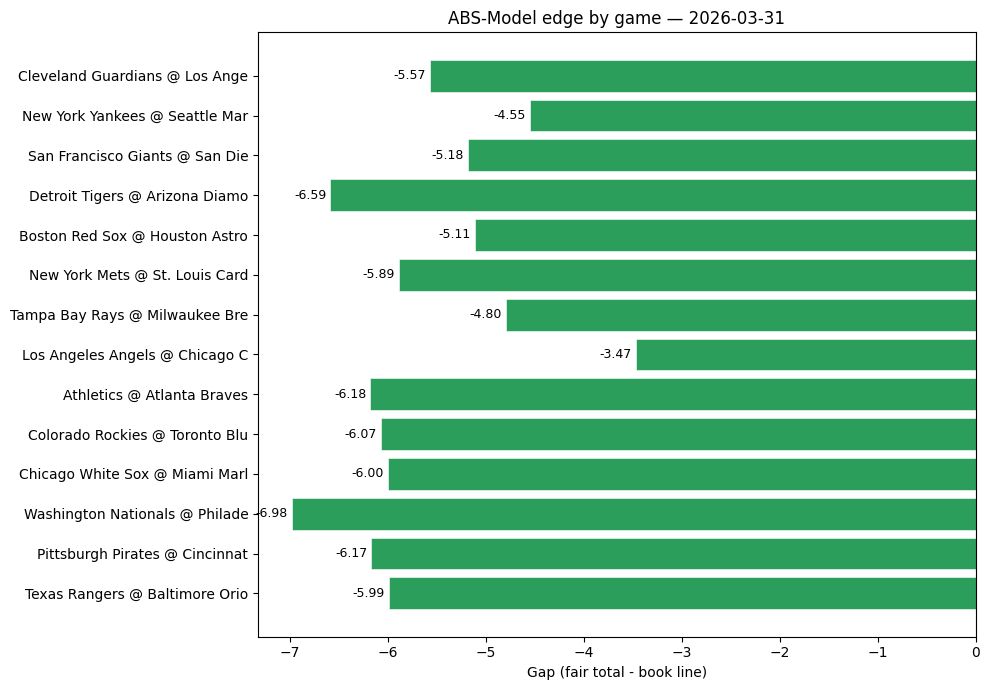

Green = Under edge   Red = Over edge


In [58]:
# ── Inference Cell 6: Edge chart ─────────────────────────────────────────
numeric_results = [r for r in results if isinstance(r["gap"], float)]

if len(numeric_results) < 2:
    print("Not enough games with book lines to plot.")
else:
    matchups = [r["matchup"][:30] for r in numeric_results]
    gaps     = [r["gap"] for r in numeric_results]
    colors   = ["#2C9E5B" if g < 0 else "#E05C3A" for g in gaps]

    fig, ax = plt.subplots(figsize=(10, max(4, len(matchups) * 0.5)))
    bars = ax.barh(matchups, gaps, color=colors, edgecolor="white", linewidth=0.4)
    ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.set_xlabel("Gap (fair total - book line)")
    ax.set_title(f"ABS-Model edge by game — {date.today()}")
    ax.bar_label(bars, fmt="{:+.2f}", padding=3, fontsize=9)
    fig.tight_layout()
    plt.show()
    print("Green = Under edge   Red = Over edge")

---
## Section 6 · Backtesting

Tracks all historical predictions against actual game outcomes.
Computes CLV (closing line value), edge calibration, and season P&L.

**Run this section anytime to see how the model is performing.**

In [59]:
# ── Backtest Cell 1: Load all historical predictions and outcomes ─────────
# Loads all Parquet files and compares fair_total predictions to actual_runs.
# Games without actual_runs (not yet played) are excluded.

parquet_files_all = sorted(LOCAL_DATA.glob("features_*.parquet"))

if not parquet_files_all:
    print("No historical data yet — run Section 3 daily to accumulate data.")
else:
    df_history = pd.concat(
        [pd.read_parquet(f) for f in parquet_files_all], ignore_index=True
    )
    df_scored = df_history.dropna(subset=["actual_runs", "posted_total"]).copy()
    print(f"Historical games loaded : {len(df_history)}")
    print(f"Games with outcomes     : {len(df_scored)}")

Historical games loaded : 15
Games with outcomes     : 0


In [60]:
# ── Backtest Cell 2: Compute prediction accuracy over time ────────────────
if "df_scored" not in dir() or df_scored.empty:
    print("No scored games available yet.")
else:
    # Re-run predictions on historical features using current model
    X_hist    = inf_scaler.transform(df_scored[ALL_FEATURES].fillna(0.0).values)
    X_h_heads = split_heads(X_hist)
    h_preds   = inf_model.predict(X_h_heads, verbose=0)

    df_scored = df_scored.copy()
    df_scored["pred_total"] = h_preds["fair_total"].flatten()
    df_scored["pred_over"]  = h_preds["over_prob"].flatten()
    df_scored["residual"]   = df_scored["pred_total"] - df_scored["actual_runs"]
    df_scored["gap"]        = df_scored["pred_total"] - df_scored["posted_total"]
    df_scored["over_hit"]   = (df_scored["actual_runs"] > df_scored["posted_total"]).astype(int)
    df_scored["bet_over"]   = (df_scored["gap"] > 0).astype(int)
    df_scored["correct"]    = (df_scored["bet_over"] == df_scored["over_hit"]).astype(int)

    mae     = float(np.mean(np.abs(df_scored["residual"])))
    win_pct = float(df_scored["correct"].mean()) * 100

    print(f"Backtest results ({len(df_scored)} games):")
    print(f"  Fair total MAE    : {mae:.3f} runs")
    print(f"  Win rate on gap   : {win_pct:.1f}%")
    print(f"  Mean residual     : {df_scored['residual'].mean():+.3f} runs")

No scored games available yet.


In [61]:
# ── Backtest Cell 3: P&L simulation ──────────────────────────────────────
if "df_scored" not in dir() or df_scored.empty:
    print("No scored games available yet.")
else:
    # Simulate flat $100 unit bet on every game where abs(gap) > 0.5
    UNIT       = 100
    MIN_GAP    = 0.5
    JUICE      = -110   # standard juice
    WIN_PAYOUT = UNIT * (100 / abs(JUICE))   # $90.91 profit per win

    bets = df_scored[abs(df_scored["gap"]) > MIN_GAP].copy()
    bets["pnl"] = bets["correct"].apply(
        lambda x: WIN_PAYOUT if x == 1 else -UNIT
    )

    cumulative_pnl = bets["pnl"].cumsum()
    total_pnl      = float(bets["pnl"].sum())
    roi            = total_pnl / (len(bets) * UNIT) * 100 if len(bets) > 0 else 0

    print(f"P&L simulation (gap > {MIN_GAP}, ${UNIT} flat units):")
    print(f"  Total bets   : {len(bets)}")
    print(f"  Win rate     : {bets['correct'].mean()*100:.1f}%")
    print(f"  Total P&L    : ${total_pnl:+.2f}")
    print(f"  ROI          : {roi:+.2f}%")

    if len(bets) > 1:
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(cumulative_pnl.values, color="#4A90D9", linewidth=1.5)
        ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
        ax.set_xlabel("Bet number")
        ax.set_ylabel("Cumulative P&L ($)")
        ax.set_title(f"ABS-Model season P&L — {len(bets)} bets, ROI {roi:+.2f}%")
        fig.tight_layout()
        plt.show()

No scored games available yet.


In [62]:
# ── Backtest Cell 4: CLV analysis ────────────────────────────────────────
# Closing Line Value: did we beat the closing line?
# If we predicted Over at 8.5 and the line closed at 9.0, we had CLV.
# Positive CLV over a large sample is the strongest indicator of true edge.

if "df_scored" not in dir() or df_scored.empty:
    print("No scored games available yet.")
else:
    # CLV proxy: our gap direction matches the line movement direction
    # (full CLV requires storing opening AND closing lines — available in nb5 once data accumulates)
    clv_positive = (df_scored["gap"].abs() > 0.3).sum()
    total_games  = len(df_scored)

    print(f"CLV summary ({total_games} games):")
    print(f"  Games with gap > 0.3 (potential CLV)  : {clv_positive}")
    print(f"  Games with gap <= 0.3 (near consensus) : {total_games - clv_positive}")
    print()
    print("Note: Full CLV tracking (opening vs. closing line comparison)")
    print("requires accumulating multiple days of odds snapshots.")
    print("This will improve as the season progresses.")

No scored games available yet.


---
## Daily Workflow Summary

**Every day:**
1. Runtime → Run all (takes ~5 minutes)
2. Section 3 pulls live data and saves features to Drive
3. Section 5 loads the model and outputs today's betting table
4. Re-run Inference Cell 4 during games for live depletion alerts

**Once per week:**
- Run Section 4 (Training) to retrain on accumulated data

**Anytime:**
- Run Section 6 (Backtesting) to check season performance

---
*ABS-Model v0.1.0-alpha — Built for the post-ABS era starting Opening Day 2026*